In [1]:
import torch
import os
os.chdir('../')

In [2]:
from scipy import linalg
import numpy as np
import os, torch
from tqdm import tqdm
from reports.util import load_config


@torch.no_grad()
def _trace_sqrtm_product(C1: torch.Tensor, C2: torch.Tensor) -> torch.Tensor:
    # Tr sqrtm(C1 @ C2) = Tr sqrt( C1^{1/2} C2 C1^{1/2} )
    s, U = torch.linalg.eigh(C1)                 # C1 = U diag(s) U^T
    s = s.clamp_min(0)
    C1h = (U * s.sqrt()) @ U.t()                 # C1^{1/2}
    M   = C1h @ C2 @ C1h
    w   = torch.linalg.eigvalsh((M + M.t()) * 0.5).clamp_min(0)
    return w.sqrt().sum()

@torch.no_grad()
def calc_fid_stats(mu1, sigma1, mu2, sigma2, eps: float = 1e-6) -> float:
    # 모두 float64 + 동일 device로 정렬
    C1 = torch.as_tensor(sigma1, dtype=torch.float64)
    device = C1.device
    C2 = torch.as_tensor(sigma2, dtype=torch.float64).to(device)
    m1 = torch.as_tensor(mu1,    dtype=torch.float64).to(device).flatten()
    m2 = torch.as_tensor(mu2,    dtype=torch.float64).to(device).flatten()

    D = m1.numel()
    I = torch.eye(D, dtype=torch.float64, device=device)

    # 대칭화 + 정칙화
    C1 = (C1 + C1.t()) * 0.5 + eps * I
    C2 = (C2 + C2.t()) * 0.5 + eps * I

    diff = m1 - m2
    tr_covmean = _trace_sqrtm_product(C1, C2)
    fid = diff.dot(diff) + torch.trace(C1) + torch.trace(C2) - 2.0 * tr_covmean
    return float(fid)

@torch.no_grad()
def calc_fid_pt_dir(pt_dir: str, mu, sigma, eps: float = 1e-6, num=100000, key="inception_feature") -> float:
    # pt_dir에서 'inception_feature'를 모아서 mu1, sigma1 추정 후 FID 계산
    X = []
    for f in tqdm(os.listdir(pt_dir)[:num]):
        if f.endswith(".pt"):
            v = torch.load(os.path.join(pt_dir, f), map_location="cpu").get(key)
            if v is not None:
                X.append(torch.as_tensor(v, dtype=torch.float64).flatten())
    if len(X) < 2:
        raise ValueError("need >=2 features")

    X   = torch.stack(X, 0)                 # [N, D]
    mu1 = X.mean(0)
    Xc  = X - mu1
    sigma1 = (Xc.t() @ Xc) / (X.shape[0] - 1)  # 불편추정

    return calc_fid_stats(mu1, sigma1, mu, sigma, eps=eps)
    #return calculate_frechet_distance(mu1, sigma1, mu, sigma, eps=eps)

def calculate_frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    """Numpy implementation of the Frechet Distance.
    The Frechet distance between two multivariate Gaussians X_1 ~ N(mu_1, C_1)
    and X_2 ~ N(mu_2, C_2) is
            d^2 = ||mu_1 - mu_2||^2 + Tr(C_1 + C_2 - 2*sqrt(C_1*C_2)).

    Stable version by Dougal J. Sutherland.

    Params:
    -- mu1   : Numpy array containing the activations of a layer of the
               inception net (like returned by the function 'get_predictions')
               for generated samples.
    -- mu2   : The sample mean over activations, precalculated on an
               representative data set.
    -- sigma1: The covariance matrix over activations for generated samples.
    -- sigma2: The covariance matrix over activations, precalculated on an
               representative data set.

    Returns:
    --   : The Frechet Distance.
    """

    mu1 = np.atleast_1d(mu1)
    mu2 = np.atleast_1d(mu2)

    sigma1 = np.atleast_2d(sigma1)
    sigma2 = np.atleast_2d(sigma2)

    assert mu1.shape == mu2.shape, \
        'Training and test mean vectors have different lengths'
    assert sigma1.shape == sigma2.shape, \
        'Training and test covariances have different dimensions'

    diff = mu1 - mu2

    # Product might be almost singular
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if not np.isfinite(covmean).all():
        msg = ('fid calculation produces singular product; '
               'adding %s to diagonal of cov estimates') % eps
        print(msg)
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))

    # Numerical error might give slight imaginary component
    if np.iscomplexobj(covmean):
        if not np.allclose(np.diagonal(covmean).imag, 0, atol=1e-3):
            m = np.max(np.abs(covmean.imag))
            raise ValueError('Imaginary component {}'.format(m))
        covmean = covmean.real

    tr_covmean = np.trace(covmean)

    return (diff.dot(diff) + np.trace(sigma1)
            + np.trace(sigma2) - 2 * tr_covmean)

In [3]:
#for nfe in [3, 5, 7, 9]:
#for nfe in [3, 4, 5, 6, 7, 8]:
for nfe in [9]:
    for pt_step in [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000, 13000, 14000, 15000, 16000, 17000, 18000, 19000, 20000]:
        pt_dir = f"samplings/GMDiT/1.4/{nfe}/Dual-Solver/10000/pt{pt_step}/mobile_0"
        if not os.path.exists(pt_dir):
            continue
        
        data = torch.load('/dataset/dit/stats.pt')
        fid = calc_fid_pt_dir(pt_dir, data['mu'], data['sigma'])
        print(pt_dir, fid)


100%|██████████| 10001/10001 [00:03<00:00, 2586.32it/s]


samplings/GMDiT/1.4/9/Dual-Solver/10000/pt1000/mobile_0 4.992990048514855


100%|██████████| 10001/10001 [00:03<00:00, 2593.67it/s]


samplings/GMDiT/1.4/9/Dual-Solver/10000/pt2000/mobile_0 4.802026212753674


100%|██████████| 10001/10001 [00:04<00:00, 2498.82it/s]


...

samplings/GMDiT/1.4/9/Dual-Solver/10000/pt18000/mobile_0 4.9755050645659935


100%|██████████| 10001/10001 [00:04<00:00, 2400.83it/s]


samplings/GMDiT/1.4/9/Dual-Solver/10000/pt19000/mobile_0 4.968810813816731


100%|██████████| 10001/10001 [00:04<00:00, 2341.32it/s]


samplings/GMDiT/1.4/9/Dual-Solver/10000/pt20000/mobile_0 4.9638004590936475


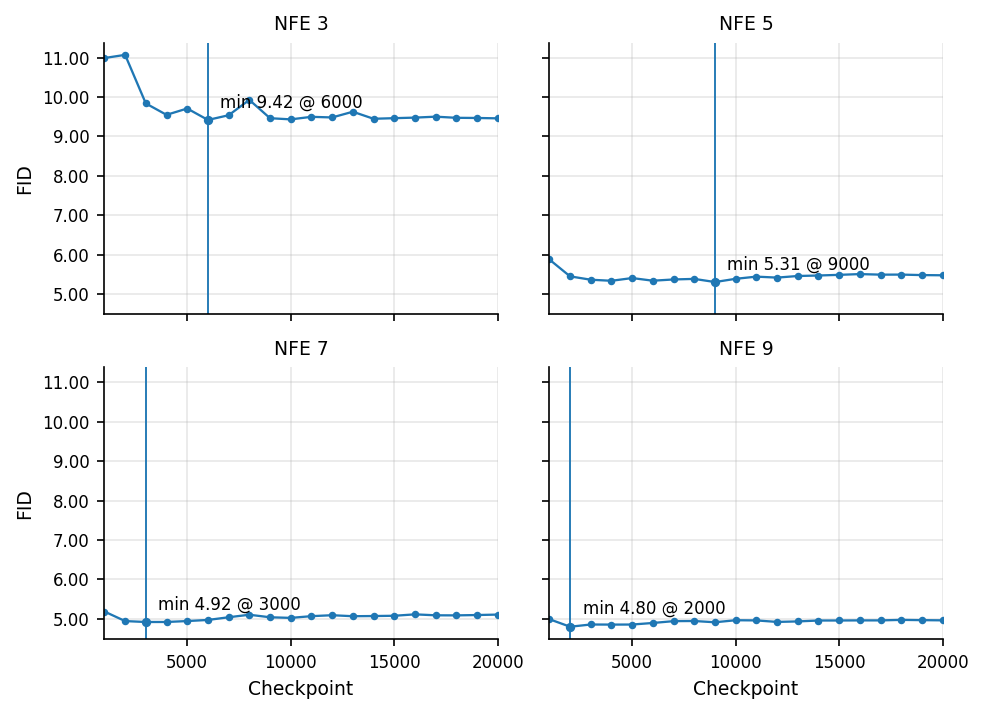

In [7]:
# 2x2 subplots — NFE 3,5,7,9
# Coarse ticks, FID 2 decimals, vline at min, NO save/show

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter

mpl.rcParams.update({
    "figure.dpi":150, "font.size":8, "axes.labelsize":9, "axes.titlesize":9,
    "axes.linewidth":0.8, "grid.alpha":0.25, "pdf.fonttype":42, "ps.fonttype":42
})

# ----- data -----
cp = [1000,2000,3000,4000,5000,6000,7000,8000,9000,10000,11000,12000,13000,14000,15000,16000,17000,18000,19000,20000]
n3 = [10.9871,11.0676,9.8360,9.5473,9.7076,9.4178,9.5371,9.9258,9.4617,9.4322,9.4967,9.4810,9.6260,9.4475,9.4628,9.4767,9.5007,9.4719,9.4678,9.4582]
n5 = [5.8811,5.4528,5.3677,5.3406,5.4099,5.3427,5.3743,5.3884,5.3089,5.3908,5.4459,5.4213,5.4619,5.4746,5.4912,5.5105,5.4962,5.4975,5.4851,5.4801]
n7 = [5.1873,4.9454,4.9215,4.9222,4.9457,4.9737,5.0419,5.1057,5.0416,5.0261,5.0698,5.0936,5.0683,5.0729,5.0796,5.1154,5.0915,5.0896,5.0984,5.1098]
n9 = [4.9930,4.8020,4.8584,4.8560,4.8574,4.8971,4.9434,4.9469,4.9150,4.9666,4.9619,4.9237,4.9365,4.9593,4.9600,4.9626,4.9623,4.9755,4.9688,4.9638]

series = [(3,n3),(5,n5),(7,n7),(9,n9)]

# shared Y range
ymin = min(min(v) for _,v in series); ymax = max(max(v) for _,v in series)
m = 0.05*(ymax - ymin); ymin, ymax = ymin - m, ymax + m

fig, axs = plt.subplots(2, 2, figsize=(6.6, 4.8), sharex=True, sharey=True)
axs = axs.ravel()

for i, (nfe, y) in enumerate(series):
    ax = axs[i]
    ax.plot(cp, y, marker="o", linewidth=1.1, markersize=2.6)
    # vline at min
    k = min(range(len(y)), key=y.__getitem__); xmin, yminv = cp[k], y[k]
    ax.axvline(xmin, linewidth=0.9); ax.scatter([xmin], [yminv], s=12, zorder=3)
    ax.annotate(f"min {yminv:.2f} @ {xmin}", (xmin, yminv),
                xytext=(6,6), textcoords="offset points")
    # styling
    ax.set_title(f"NFE {nfe}")
    ax.set_ylim(ymin, ymax); ax.set_xlim(min(cp), max(cp))
    ax.xaxis.set_major_locator(MultipleLocator(5000))
    ax.yaxis.set_major_locator(MultipleLocator(1.0))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v,_: f"{v:.2f}"))
    ax.grid(True, which="major", alpha=0.3)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    if i // 2 == 1: ax.set_xlabel("Checkpoint")
    if i % 2 == 0:  ax.set_ylabel("FID")

fig.tight_layout()
# no save, no show
